# NFW host: shell-based heating vs SatGen DASH/Green

Same subhalo and heating prescription as `stripping_sis.ipynb` (Benson+Du22 spec: NFW with $M(<r_{\max}) = 10^6\,M_\odot$, $r_s = 0.22\,\mathrm{kpc}$, exp-truncated at $10\,r_s$; $\gamma_h = 1.5$; $f_2 = 0.406$; $\chi_v = -0.333$), but the host is an NFW profile (Milky-Way scale, Du+22 parameters) instead of the Singular Isothermal Sphere used by Benson, Du, Errani, and Navarro for the canonical tidal-track comparison.

The primary Benson+Du22 reproduction lives in `stripping_sis.ipynb`. This notebook checks that the shell-based prescription tracks SatGen's built-in DASH/Green evolution on a Milky-Way-scale host:

- **SatGen DASH/Green:** `ev.msub` + `Green.update_mass(m)`, reshaping the profile via the Green+19 DASH transfer function — exponentially truncated NFW, no tail regeneration. This is what `SubEvo.py` does.
- **Du+24 shell heating, first-order:** `heat_profile` from `subhalo_functions.py` applies the Du+24 monotonic shell-expansion formalism on a per-step $\varepsilon(r) \propto r^2$ injection.
- **Du+24 + Benson+Du22 second-order:** adds the Benson+Du22 $\varepsilon_2 \propto \sqrt{\varepsilon_1\,\sigma_r^2}$ correction (eq. 4), applied per timestep so the per-step increments add up to the per-orbit shock.

The naive SatGen P10/Dekel prescription (the `SatEvo.py` pattern that re-fits a Dekel profile every step) is layered on at the end so all four are on the same axes; `stripping.ipynb` zooms in on its over-stripping behaviour at UFD scale.

In [1]:
import numpy as np
import time

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt

%matplotlib inline

%load_ext autoreload
%autoreload 2
import config as cfg
from profiles import NFW, Dekel
from subhalo_functions import NumericProfile
import stripping_common as sc

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Setup

NFW host (Milky-Way scale) plus the Benson+Du22 test subhalo. Concentration is solved numerically so that the resulting NFW has $r_s = 0.22\,\mathrm{kpc}$ and $M(<r_{\max}) = 10^6\,M_\odot$ at the same time — Benson+Du22 specify the mass within $r_{\max}$, not $M_{\rm vir}$, so the $(M_{\rm vir}, c)$ pair is constrained.

In [2]:
cfg.Mres = 1e1

#---host parameters (Milky-Way scale NFW, Du+22 params)
Mv    = 3.7e12        # host virial mass [Msun]
cNFW  = 11.68         # host NFW concentration

#---subhalo: NFW with M(<r_max) = 1e6 Msun and r_s = 0.22 kpc, exponentially
#   truncated at 10 r_s. Same spec as in stripping_sis.ipynb (the test subhalo
#   in Benson+Du22). M(<r_max), not M_vir, is what Benson+Du22 specify, so we
#   solve for the concentration that gives the right (r_s, M(<r_max)) pair.
from scipy.optimize import brentq
rs_target  = 0.22
M_in_rmax  = 1e6
mu_at_rmax = np.log(1. + 2.163) - 2.163 / (1. + 2.163)

def _err(c):
    mu_c  = np.log(1. + c) - c / (1. + c)
    M_vir = M_in_rmax * mu_c / mu_at_rmax
    return NFW(M_vir, c).rs - rs_target

cNFW_sub = brentq(_err, 1., 100.)
mu_c     = np.log(1. + cNFW_sub) - cNFW_sub / (1. + cNFW_sub)
mv0      = M_in_rmax * mu_c / mu_at_rmax
sat_nfw  = NFW(mv0, cNFW_sub)

#---tidal heating parameters (Benson+Du22 calibration: gamma=1.5 slow shocks,
#   eps_h from Pullen+14)
epsh  = 3.
gamma = 1.5

#---time integration
Nstep = 30000
tmax  = 30.           # [Gyr]

#---host and orbit
hNFW   = NFW(Mv, cNFW)
R0, z0 = 0.7 * hNFW.rh, 0.
xv0, _ = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=0.21)

#---subhalo radial grid: truncate at 10*r_s (Benson+Du22 truncation)
r_trunc_sub = 10. * sat_nfw.rs
rvals       = np.logspace(np.log10(cfg.Rres), np.log10(r_trunc_sub), 100)
M_sub_arr   = sat_nfw.M(rvals)
M_tot_sub   = M_sub_arr[-1]

from profiles import tdyn as _tdyn
dt = tmax / Nstep
print(f"Host NFW : Mvir={Mv:.2e} Msun, c={cNFW:.2f}, rh={hNFW.rh:.1f} kpc")
print(f"Sub  NFW : Mvir={mv0:.2e} Msun, c={cNFW_sub:.2f}, "
      f"rs={sat_nfw.rs:.3f} kpc, rmax={sat_nfw.rmax:.3f} kpc, "
      f"Vmax={sat_nfw.Vmax:.3f} kpc/Gyr ({sat_nfw.Vmax/1.022:.2f} km/s)")
print(f"           rtrunc=10*rs={r_trunc_sub:.2f} kpc, M(<rtrunc)={M_tot_sub:.2e} Msun")
print(f"Orbit    : R0={R0:.1f} kpc, eta=0.21")
print(f"dt={dt:.5f} Gyr, t_dyn(R0)={_tdyn(hNFW, R0):.4f} Gyr, "
      f"dt/t_dyn={dt/_tdyn(hNFW,R0):.3f}")

Host NFW : Mvir=3.70e+12 Msun, c=11.68, rh=319.1 kpc
Sub  NFW : Mvir=3.89e+06 Msun, c=14.75, rs=0.220 kpc, rmax=0.476 kpc, Vmax=3.075 kpc/Gyr (3.01 km/s)
           rtrunc=10*rs=2.20 kpc, M(<rtrunc)=3.18e+06 Msun
Orbit    : R0=223.3 kpc, eta=0.21
dt=0.00100 Gyr, t_dyn(R0)=1.4202 Gyr, dt/t_dyn=0.001


## SatGen DASH/Green baseline

Mirrors `SubEvo.py`: construct a `Green(mv0, cNFW_sub)` profile and evolve it with
`ev.msub` (King62 mass loss). After each step `s.update_mass(m)` reshapes the profile
via the DASH transfer function — exponentially truncated NFW, no Dekel refit.

In [3]:
t0 = time.time()
result_B = sc.evolve_satgen_green(
    hNFW, mv0, cNFW_sub, xv0,
    tmax=tmax, Nstep=Nstep, alpha='conc'
)
print(f"SatGen DASH/Green: {time.time()-t0:.1f} s")
print(f"  rmax0={result_B.rmax0:.3f} kpc, vmax0={result_B.vmax0:.3f} kpc/Gyr")
print(f"  final m = {result_B.m[result_B.m>0][-1]:.2e} Msun")

SatGen DASH/Green: 54.2 s
  rmax0=0.476 kpc, vmax0=3.074 kpc/Gyr
  final m = 3.89e+01 Msun


## Du+24 tidal heating with NFW seed

Same subhalo wrapped into a `NumericProfile` and evolved with `heat_profile` (Du+24 monotonic shell expansion) plus King62 tidal stripping.

In [4]:
numProfile0 = NumericProfile(rvals, M_sub_arr)

t0 = time.time()
result_heat = sc.evolve_heating(
    hNFW, numProfile0, xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma,
)
print(f"Du+24 heating (NFW seed): {time.time()-t0:.1f} s")
print(f"  rmax0={result_heat.rmax0:.3f} kpc, vmax0={result_heat.vmax0:.3f} kpc/Gyr "
      f"({result_heat.vmax0/1.022:.2f} km/s)")
print(f"  final m/M_tot = {result_heat.m[result_heat.m>0][-1]/M_tot_sub:.3e}")

#---dt vs t_dyn check along the orbit
r_orbit    = result_heat.r[result_heat.r > 0]
tdyn_orbit = np.array([_tdyn(hNFW, rr) for rr in r_orbit])
print(f"  t_dyn over orbit: min={tdyn_orbit.min():.4f}, "
      f"median={np.median(tdyn_orbit):.4f}, max={tdyn_orbit.max():.4f} Gyr")
print(f"  dt/t_dyn_min = {dt/tdyn_orbit.min():.3f}  (want << 1)")

Du+24 heating (NFW seed): 72.5 s
  rmax0=0.476 kpc, vmax0=3.075 kpc/Gyr (3.01 km/s)
  final m/M_tot = 4.439e-03
  t_dyn over orbit: min=0.1185, median=1.1046, max=1.4202 Gyr
  dt/t_dyn_min = 0.008  (want << 1)


## Second-order tidal heating (Benson+Du22)

Adds the [Benson+Du22](https://academic.oup.com/mnras/article/517/1/1398/6726643) second-order correction to the per-shell energy injection (their eq. 4):

$$\Delta\varepsilon(r) = \Delta\varepsilon_1(r) + \sqrt{2}\, f_2 (1+\chi_v)\, \sqrt{\Delta\varepsilon_1(r)\, \sigma_r^2(r)},$$

with $f_2 = 0.406$, $\chi_v = -0.333$, and $\sigma_r$ the radial velocity dispersion (`NumericProfile.sigma`, the isotropic-Jeans solution). The radial dependence differs from $\varepsilon_1 \propto r^2$ — heating is boosted at small radii where $\sigma_r$ is large — and is expected to push the tidal track off the first-order curve at intermediate stripping.

Same `evolve_heating` entry point with `second_order=True`.

In [5]:
t0 = time.time()
result_heat2 = sc.evolve_heating(
    hNFW, NumericProfile(rvals, M_sub_arr), xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma,
    second_order=True,
)
print(f"Du+24 heating + Benson+Du22 2nd-order (NFW seed): {time.time()-t0:.1f} s")
print(f"  rmax0={result_heat2.rmax0:.3f} kpc, vmax0={result_heat2.vmax0:.3f} kpc/Gyr "
      f"({result_heat2.vmax0/1.022:.2f} km/s)")
print(f"  final m/M_tot = {result_heat2.m[result_heat2.m>0][-1]/M_tot_sub:.3e}")

Du+24 heating + Benson+Du22 2nd-order (NFW seed): 108.2 s
  rmax0=0.476 kpc, vmax0=3.075 kpc/Gyr (3.01 km/s)
  final m/M_tot = 9.569e-05


## Comparison: tidal tracks and mass loss

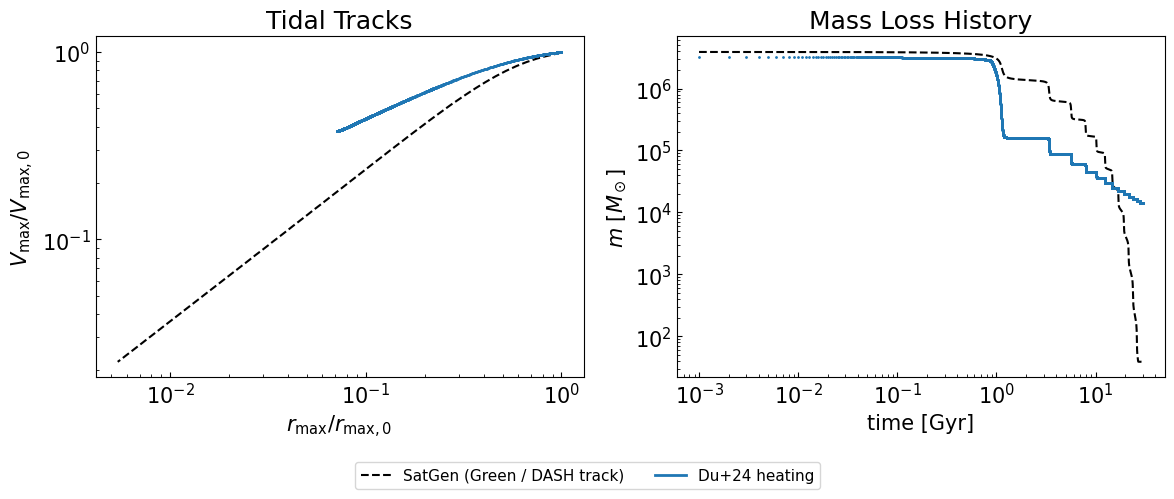

In [6]:
#---Green/DASH baseline in black dashed; heating in default scatter
styles = [
    dict(color='black', linestyle='--', linewidth=1.5),   # Green / DASH
    None,                                                 # Du+24 heating
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([result_B, result_heat], ax=axes[0],
                    styles=styles, legend=False)
sc.plot_mass_loss([result_B, result_heat], ax=axes[1],
                  styles=styles, legend=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(sc.markers_to_lines(handles), labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

### First-order vs second-order

Overplot `result_heat` against `result_heat2` on the same axes, with the Green/DASH
baseline in dashed black for reference (mirroring the 1st-order plot above).
Expect 2nd-order to lie below the 1st-order track at intermediate stripping
(more aggressive heating, faster mass loss).

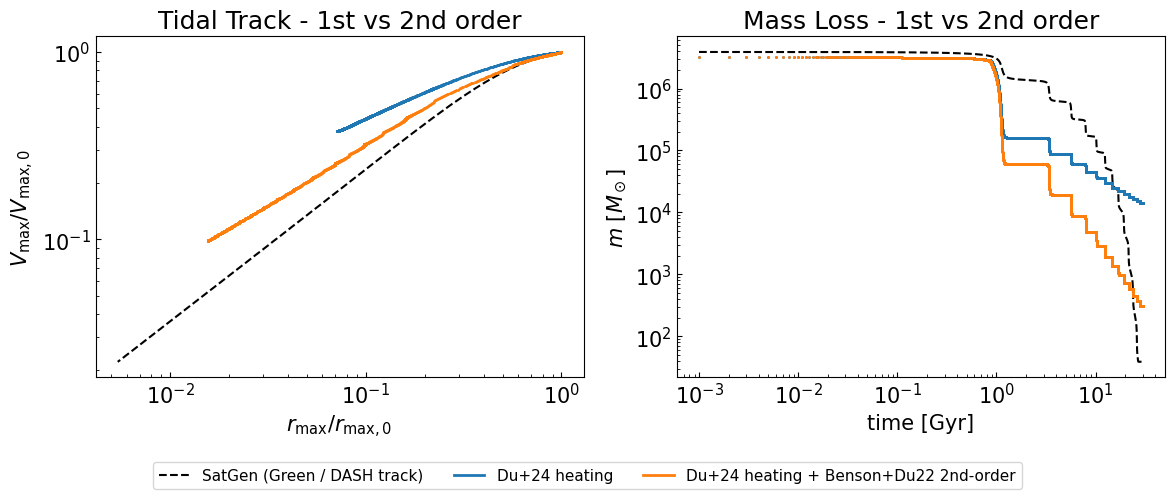

In [7]:
styles = [
    dict(color='black', linestyle='--', linewidth=1.5),   # Green / DASH (reference)
    None,                                                 # Du+24 heating, 1st order
    None,                                                 # Du+24 heating, 1st + 2nd order
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([result_B, result_heat, result_heat2], ax=axes[0],
                    styles=styles, title='Tidal Track - 1st vs 2nd order',
                    legend=False)
sc.plot_mass_loss([result_B, result_heat, result_heat2], ax=axes[1],
                  styles=styles, title='Mass Loss - 1st vs 2nd order',
                  legend=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(sc.markers_to_lines(handles), labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## Profile evolution snapshots

Density, enclosed mass, and circular velocity at evenly-spaced time snapshots.
Colour runs from dark (early) to light (late).

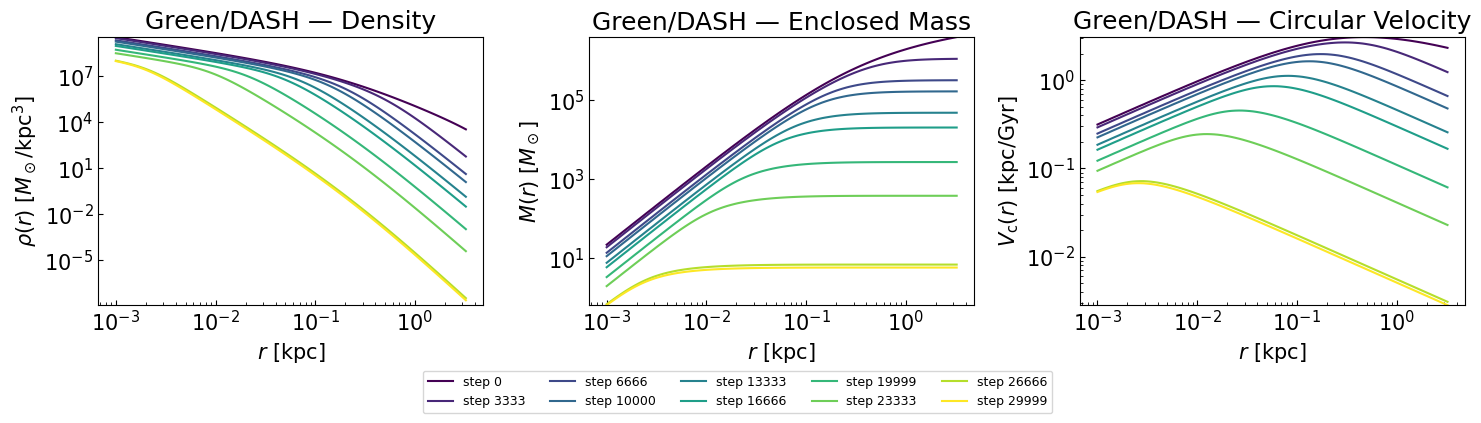

In [8]:
shared_ylims = sc.profile_ylims(result_B, result_heat, result_heat2)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(result_B, axes=axes, title_prefix='Green/DASH — ', ylims=shared_ylims)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

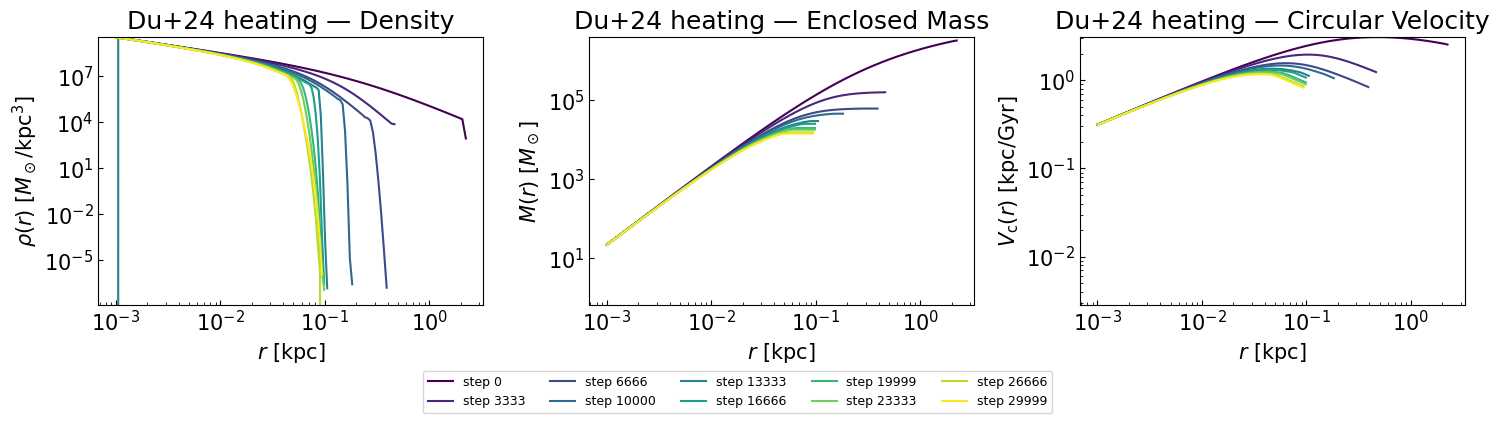

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(result_heat, axes=axes, title_prefix='Du+24 heating — ', ylims=shared_ylims)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

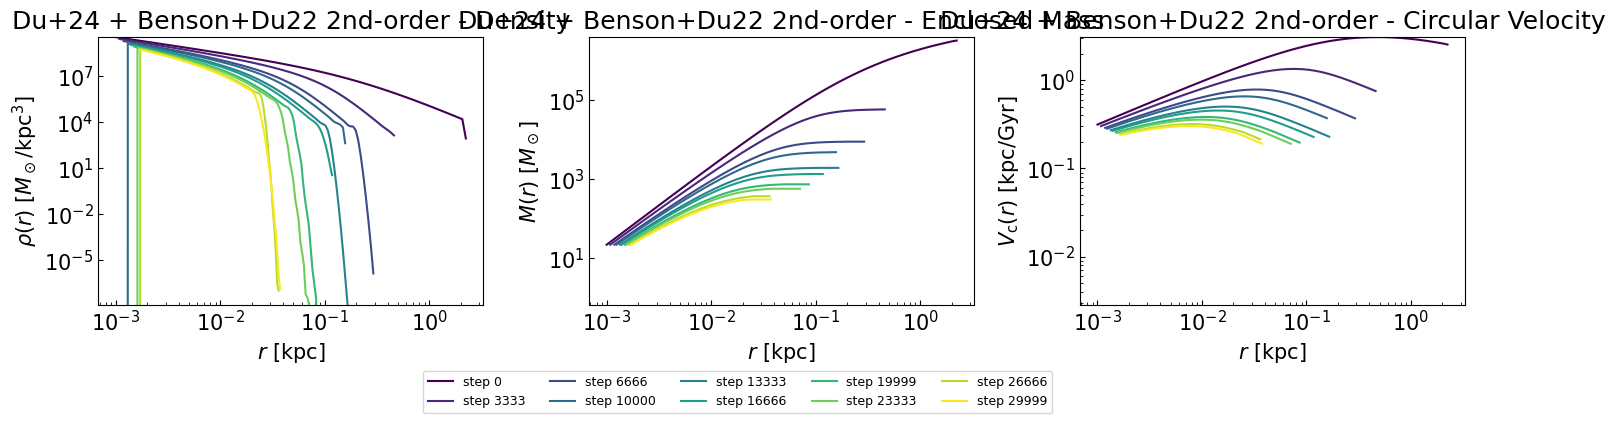

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(result_heat2, axes=axes,
                          title_prefix='Du+24 + Benson+Du22 2nd-order - ', ylims=shared_ylims)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

## Orbital radius evolution

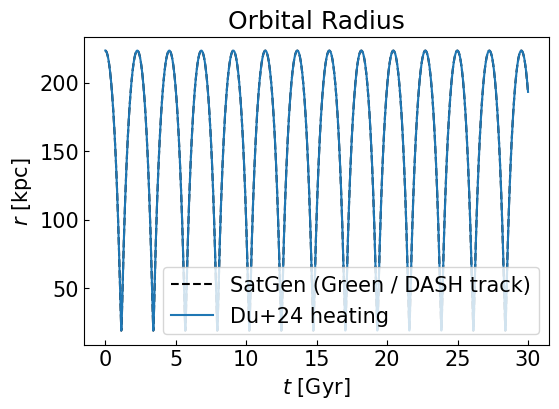

In [11]:
sc.plot_orbit(
    [result_B, result_heat],
    styles=[
        dict(color='black', linestyle='--', linewidth=1.5),   # Green / DASH
        None,                                                 # Du+24 heating
    ],
)
plt.show()

## Adding the SatGen P10/Dekel prescription

Run the SatGen P10/Dekel evolution on the same host and orbit so all four
prescriptions land on the same axes — tidal track, mass loss, and orbital
radius.

SatGen P10/Dekel: 36.7 s


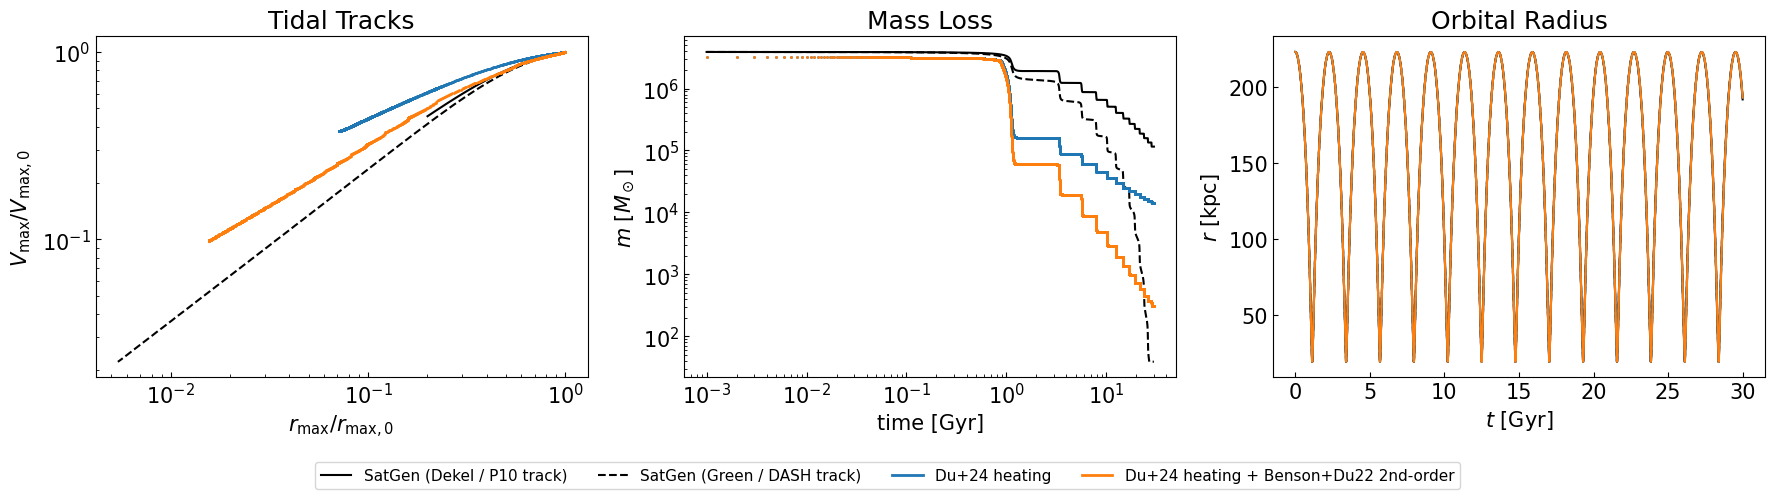

In [12]:
sat_dekel = Dekel(mv0, 100., 1.0 + cfg.eps)

t0 = time.time()
result_A = sc.evolve_satgen_dekel(hNFW, sat_dekel, xv0, tmax=tmax, Nstep=Nstep)
print(f"SatGen P10/Dekel: {time.time()-t0:.1f} s")

#---SatGen baselines in black with distinct line styles, heating results in default colours
results_all = [result_A, result_B, result_heat, result_heat2]
styles_track = [
    dict(color='black', linestyle='-',  linewidth=1.5),   # SatGen P10/Dekel
    dict(color='black', linestyle='--', linewidth=1.5),   # SatGen DASH/Green
    None,                                                 # Du+24 heating
    None,                                                 # Du+24 + Benson+Du22
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.plot_tidal_track(results_all, ax=axes[0], title='Tidal Tracks',
                    styles=styles_track, legend=False)
sc.plot_mass_loss(results_all, ax=axes[1], title='Mass Loss',
                  styles=styles_track, legend=False)
sc.plot_orbit(results_all, ax=axes[2], title='Orbital Radius',
              styles=styles_track, legend=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(sc.markers_to_lines(handles), labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=len(results_all), fontsize=11)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()